# Skin Lesion Segmentation

---  
## 1. Khởi tạo môi trường và cố định seed

In [1]:
import os
import math
import random
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

import warnings
warnings.filterwarnings('ignore')

# Kiểm tra phiên bản và thiết bị phần cứng
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()} (Device: {device})")

# Hàm cố định Seed để đảm bảo tính tái lập (Reproducibility)
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Đã cố định Random Seed = 42")


PyTorch Version : 2.7.1+cu118
CUDA Available  : True (Device: cuda)
Đã cố định Random Seed = 42


---  
## 2. Chuẩn bị dữ liệu và data augmentation

Dữ liệu đã được tiền xử lý và lưu dưới dạng các file numpy (`.npy`) giúp nạp toàn bộ vào RAM để tăng tốc độ huấn luyện tối đa.

### 2.1. Các hàm data augmentation

In [2]:
def color_jitter(img: np.ndarray) -> np.ndarray:
    """Điều chỉnh ngẫu nhiên độ sáng, độ tương phản và sắc độ (Hue/Saturation)."""
    # 1. Brightness & Contrast
    alpha = random.uniform(0.8, 1.2)   # Contrast
    beta = random.uniform(-20, 20)     # Brightness
    img = np.clip(alpha * img.astype(float) + beta, 0, 255).astype(np.uint8)

    # 2. Saturation & Hue trong không gian HSV
    if random.random() > 0.5:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(float)
        hsv[:, :, 0] = (hsv[:, :, 0] + random.uniform(-10, 10)) % 180  # Hue
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * random.uniform(0.8, 1.2), 0, 255)  # Saturation
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    return img

In [3]:
def random_rotate_and_crop(img: np.ndarray, mask: np.ndarray, img_size=(256, 256)):
    """Xoay tự do góc (-45 đến +45 độ) và Random Crop & Resize đồng bộ."""
    h, w = img_size
    # Random Rotate
    if random.random() > 0.5:
        angle = random.uniform(-45, 45)
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)

    # Random Crop & Resize
    if random.random() > 0.5:
        scale = random.uniform(0.8, 1.0)
        new_h, new_w = int(h * scale), int(w * scale)
        top = random.randint(0, h - new_h)
        left = random.randint(0, w - new_w)
        
        img = img[top:top + new_h, left:left + new_w]
        mask = mask[top:top + new_h, left:left + new_w]

        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    return img, mask

In [4]:
def apply_augmentations(img: np.ndarray, mask: np.ndarray):
    """Tổng hợp toàn bộ các phép biến đổi data augmentation khi training."""
    # 1. Horizontal Flip
    if random.random() > 0.5:
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()

    # 2. Vertical Flip
    if random.random() > 0.5:
        img = np.flipud(img).copy()
        mask = np.flipud(mask).copy()

    # 3. Transpose (Đổi trục X, Y)
    if random.random() > 0.5:
        img = np.transpose(img, (1, 0, 2)).copy()
        mask = np.transpose(mask, (1, 0)).copy()

    # 4. Random 90-degree Rotation
    k = random.choice([0, 1, 2, 3])
    if k > 0:
        img = np.rot90(img, k, (0, 1)).copy()
        mask = np.rot90(mask, k, (0, 1)).copy()

    # 5. Rotation tự do & Random Cropping
    img, mask = random_rotate_and_crop(img, mask)

    # 6. Color Jitter (Chỉ áp dụng lên ảnh)
    if random.random() > 0.5:
        img = color_jitter(img)

    return img, mask

### 2.2. Dataset và dataloader

In [5]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "2"

class FastSkinDataset(Dataset):
    """Dataset nạp sẵn dữ liệu vào RAM để tối ưu tốc độ đọc đĩa."""
    def __init__(self, data_dir, is_train=False):
        self.is_train = is_train

        images_path = os.path.join(data_dir, "images.npy")
        masks_path = os.path.join(data_dir, "masks.npy")
        ids_path = os.path.join(data_dir, "image_ids.npy")

        self.images = np.load(images_path)
        self.masks = np.load(masks_path) if os.path.exists(masks_path) else None
        self.image_ids = np.load(ids_path) if os.path.exists(ids_path) else None

        # Mean & Std chuẩn ImageNet
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        if self.masks is not None:
            mask = self.masks[idx]

            # Áp dụng Augmentation khi Training
            if self.is_train:
                image, mask = apply_augmentations(image, mask)

            # Chuẩn hóa ảnh: (H, W, 3) -> (3, H, W) [0, 1] và trừ Mean/Std
            image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
            image = torch.from_numpy(image).permute(2, 0, 1).float()
            mask = torch.from_numpy(mask).float().unsqueeze(0)

            return image, mask

        # Test Inference (không có mask)
        image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        sample_id = self.image_ids[idx] if self.image_ids is not None else str(idx)
        return image, sample_id


def get_dataloaders(processed_base=DATA_DIR, batch_size=16, num_workers=0):
    """Tạo DataLoaders cho các tập Train, Validation và Test."""
    train_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "train_256"), is_train=True),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=True
    )

    val_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "val_256"), is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )

    test_loader = DataLoader(
        FastSkinDataset(os.path.join(processed_base, "test_256"), is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        drop_last=False
    )

    return train_loader, val_loader, test_loader

### 2.3. Trực quan hoá mẫu dữ liệu từ dataloader

Images Shape       : torch.Size([16, 3, 256, 256]) (dtype: torch.float32)
Masks Shape        : torch.Size([16, 1, 256, 256]) (dtype: torch.float32)
Mask Unique Values : [0.0, 1.0]


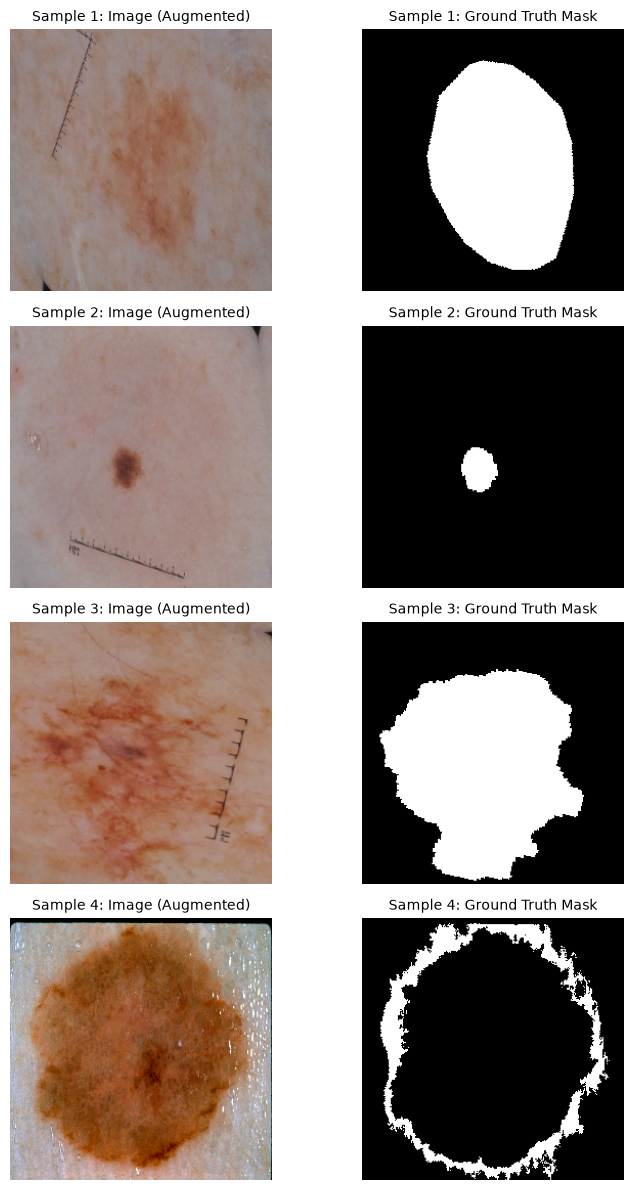

In [22]:
train_loader, val_loader, _ = get_dataloaders(batch_size=16, num_workers=0)
sample_images, sample_masks = next(iter(train_loader))

print(f"Images Shape       : {sample_images.shape} (dtype: {sample_images.dtype})")
print(f"Masks Shape        : {sample_masks.shape} (dtype: {sample_masks.dtype})")
print(f"Mask Unique Values : {torch.unique(sample_masks).tolist()}")

# Vẽ 4 mẫu ảnh và mask tương ứng
fig, axes = plt.subplots(4, 2, figsize=(8, 12))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(4):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)
    mask = sample_masks[i, 0].numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Sample {i+1}: Image (Augmented)", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask", fontsize=10)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

---  
## 3. Kiến trúc Mô hình

Lựa chọn kiến trúc **UNet** làm baseline:


In [35]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class ContextModule(nn.Module):
    """
    Context Module đa tỉ lệ (Dilated Convolutions)
    Được trang bị BatchNorm2d + Residual Connection để triệt tiêu 100% nổ gradient.
    """
    def __init__(self, in_channels, out_channels=None, dilations=[1, 2, 4, 8]):
        super().__init__()
        if out_channels is None:
            out_channels = in_channels
        layers = []
        C = in_channels
        for d in dilations:
            layers.append(nn.Sequential(
                nn.Conv2d(C, C, kernel_size=3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(C),
                nn.ReLU(inplace=True)
            ))
        self.layers = nn.Sequential(*layers)
        self.conv_final = nn.Conv2d(C, out_channels, kernel_size=1, bias=False)
        self.bn_final = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        # Khởi tạo Kaiming chuẩn cho mạng tích chập sâu
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    def forward(self, x):
        res = x
        out = self.layers(x)
        out = self.bn_final(self.conv_final(out))
        return self.relu(out + res)  # Residual connection giữ tín hiệu ổn định tuyệt đối
    
    
    
class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, bilinear=True, use_context=True):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # --- Thêm context module tại bottle neck-- 
        self.use_context = use_context
        if use_context: 
            bottleneck_channels = 1024 // factor 
            self.context = ContextModule(bottleneck_channels, bottleneck_channels)
        
        
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # --- Áp dụng Context Module ---
        if self.use_context:
            x5 = self.context(x5)   # giữ nguyên kích thước và số kênh
        # ------------------------------
        
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

---  
## 5. Loss Function And Evaluation Metrics

In [36]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred: torch.Tensor, target: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:
    """Soft Dice Loss hỗ trợ tính gradient trực tiếp."""
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return 1.0 - dice.mean()


def combined_loss(pred: torch.Tensor, target: torch.Tensor, alpha: float = 0.5) -> torch.Tensor:
    """Kết hợp BCEWithLogitsLoss và DiceLoss."""
    return alpha * bce_loss(pred, target) + (1.0 - alpha) * dice_loss(pred, target)


def dice_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, smooth: float = 1e-6) -> float:
    """Tính Dice Coefficient cho batch dữ liệu."""
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)
    return dice.mean().item()

---  
## 6. Callbacks và trực quan hóa

In [37]:
class EarlyStopping:
    """Dừng sớm nếu metric theo dõi không cải thiện sau `patience` epochs."""
    def __init__(self, patience=5, min_delta=1e-4, mode="max", save_path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.save_path = save_path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_metric = -float("inf") if mode == "max" else float("inf")

    def __call__(self, current_metric, model, epoch=None, optimizer=None):
        score = current_metric if self.mode == "max" else -current_metric

        if self.best_score is None:
            self.best_score = score
            self.best_metric = current_metric
            self.save_checkpoint(epoch, model, optimizer)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_metric = current_metric
            self.save_checkpoint(epoch, model, optimizer) 
            self.counter = 0

    def save_checkpoint(self, epoch, model, optimizer):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_metric": self.best_metric,
        }
        torch.save(checkpoint, self.save_path)

In [38]:
def log_predictions(samples, current_epoch, num_samples=4):
    """
    Tạo 1 ảnh tổng hợp so sánh trực quan 3 cột:
    Cột 1: Ảnh gốc | Cột 2: Ground Truth Mask | Cột 3: Model Prediction
    """
    images, masks, preds = samples
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3.5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_samples):
        # 1. Un-normalize ảnh RGB
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip((img * std + mean), 0, 1)

        # 2. Lấy mask 2D
        gt = masks[i].squeeze().numpy()
        pred = preds[i].squeeze().numpy()

        # Cột 1: Ảnh gốc
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Sample {i+1}: Input Image", fontsize=11, fontweight="bold")
        axes[i, 0].axis("off")

        # Cột 2: Ground Truth
        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title(f"Sample {i+1}: Ground Truth Mask", fontsize=11, color="green", fontweight="bold")
        axes[i, 1].axis("off")

        # Cột 3: Prediction
        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Sample {i+1}: Model Prediction", fontsize=11, color="blue", fontweight="bold")
        axes[i, 2].axis("off")

    plt.suptitle(f"--- VALIDATION PREDICTIONS (EPOCH {current_epoch}) ---", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---  
## 7. Huấn luyện và đánh giá

In [39]:
def train_one_epoch(model, loader, optimizer, device, current_epoch, scaler, criterion=combined_loss):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Train Epoch {current_epoch+1}", leave=False)

    for batch_idx, (images, masks) in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_dice += dice_score(outputs.detach(), masks) * batch_size

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "dice": f"{dice_score(outputs.detach(), masks):.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.2e}"
        })

    return running_loss / len(loader.dataset), running_dice / len(loader.dataset)

In [40]:
@torch.no_grad()
def validate_one_epoch(model, loader, device, current_epoch, criterion=combined_loss, use_amp=True):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    val_samples = None

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Val Epoch {current_epoch+1}", leave=False)

    for batch_idx, (images, masks) in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if use_amp and device.type == 'cuda':
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_dice += dice_score(outputs, masks) * batch_size

        pbar.set_postfix({
            "val_loss": f"{loss.item():.4f}",
            "val_dice": f"{dice_score(outputs, masks):.4f}"
        })

        if batch_idx == 0:
            val_samples = (
                images.cpu(),
                masks.cpu(),
                (torch.sigmoid(outputs) > 0.5).float().cpu()
            )

    return running_loss / len(loader.dataset), running_dice / len(loader.dataset), val_samples

In [41]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    epochs=30,
    patience=5,
    criterion=combined_loss,
    save_dir="../checkpoints/context_module_unet",
    use_amp=True
):
    """Toàn bộ vòng lặp huấn luyện, đánh giá, scheduler, earlystopping"""
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_model.pth")
    
    early_stopping = EarlyStopping(patience=patience, mode="max", save_path=best_model_path)
    total_start_time = time.time()
    
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == 'cuda'))

    total_start_time = time.time()
    print(f"Bắt đầu huấn luyện trên thiết bị: {device} ({epochs} Epochs | Patience: {patience})")
    print("=" * 75)
    
    for epoch in range(epochs):
        epoch_start_time = time.time()

        # 1. Huấn luyện – truyền scaler
        train_loss, train_dice = train_one_epoch(
            model, train_loader, optimizer, device, epoch, scaler, criterion
        )

        # 2. Đánh giá – truyền use_amp
        val_loss, val_dice, val_samples = validate_one_epoch(
            model, val_loader, device, epoch, criterion, use_amp
        )


        # 3. Cập nhật Learning Rate Scheduler
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_duration = time.time() - epoch_start_time

        # 4. In thông tin Epoch
        print(
            f"Epoch [{epoch+1:02d}/{epochs:02d}] ({epoch_duration:.1f}s) | "
            f"Train Loss: {train_loss:.4f} - Dice: {train_dice:.4f} | "
            f"Val Loss: {val_loss:.4f} - Dice: {val_dice:.4f} | "
            f"LR: {current_lr:.2e}"
        )


        # 6. Kiểm tra early stopping và lưu best model
        early_stopping(val_dice, model, epoch=epoch+1, optimizer=optimizer)
        if early_stopping.early_stop:
            print(f"\nDỪNG SỚM (Early Stopping) tại Epoch {epoch+1}! Metric không tăng sau {patience} epochs.")
            break

    # 7. Log hình ảnh dự đoán ở epoch cuối
    log_predictions(val_samples, current_epoch=epoch+1)

    total_time = time.time() - total_start_time
    print("=" * 75)
    print(f"Hoàn thành huấn luyện trong {total_time/60:.2f} phút. Best Val Dice: {early_stopping.best_metric:.4f}")

---  
## 8. Thực thi huấn luyện 

In [42]:
config = {
    "architecture": "UNet",
    "dataset": "ISIC-256",
    "image_size": 256,
    "batch_size": 16,
    "epochs": 20,                       
    "patience": 4,                     
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
}

In [43]:
# 2. Chuẩn bị Dataloaders
train_loader, val_loader, test_loader = get_dataloaders(batch_size=config["batch_size"], num_workers=0)

In [44]:
# 3. Khởi tạo mô hình 
model = UNet(n_channels=3, n_classes=1, bilinear=True).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Khởi tạo {config['architecture']} thành công | Tổng số tham số: {total_params:,}")

Khởi tạo UNet thành công | Tổng số tham số: 23,095,809


In [45]:
# 4. Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=config["epochs"], eta_min=1e-5)

Bắt đầu huấn luyện trên thiết bị: cuda (20 Epochs | Patience: 4)


Epoch [01/20] (63.7s) | Train Loss: 0.4961 - Dice: 0.6655 | Val Loss: 0.4050 - Dice: 0.7753 | LR: 9.94e-05


Epoch [02/20] (64.1s) | Train Loss: 0.4156 - Dice: 0.7248 | Val Loss: 0.4044 - Dice: 0.7438 | LR: 9.78e-05
EarlyStopping Counter: 1/4


Epoch [03/20] (66.6s) | Train Loss: 0.3691 - Dice: 0.7731 | Val Loss: 0.3348 - Dice: 0.7930 | LR: 9.51e-05


Epoch [04/20] (70.7s) | Train Loss: 0.3364 - Dice: 0.7915 | Val Loss: 0.3064 - Dice: 0.8508 | LR: 9.14e-05


...

Epoch [15/20] (71.1s) | Train Loss: 0.1802 - Dice: 0.8725 | Val Loss: 0.1480 - Dice: 0.8971 | LR: 2.32e-05


Epoch [16/20] (71.7s) | Train Loss: 0.1711 - Dice: 0.8792 | Val Loss: 0.1460 - Dice: 0.8966 | LR: 1.86e-05
EarlyStopping Counter: 1/4


Epoch [17/20] (67.3s) | Train Loss: 0.1744 - Dice: 0.8746 | Val Loss: 0.1514 - Dice: 0.8943 | LR: 1.49e-05
EarlyStopping Counter: 2/4


Epoch [18/20] (70.1s) | Train Loss: 0.1674 - Dice: 0.8799 | Val Loss: 0.1495 - Dice: 0.8945 | LR: 1.22e-05
EarlyStopping Counter: 3/4


Epoch [19/20] (67.5s) | Train Loss: 0.1645 - Dice: 0.8809 | Val Loss: 0.1379 - Dice: 0.8967 | LR: 1.06e-05
EarlyStopping Counter: 4/4

DỪNG SỚM (Early Stopping) tại Epoch 19! Metric không tăng sau 4 epochs.


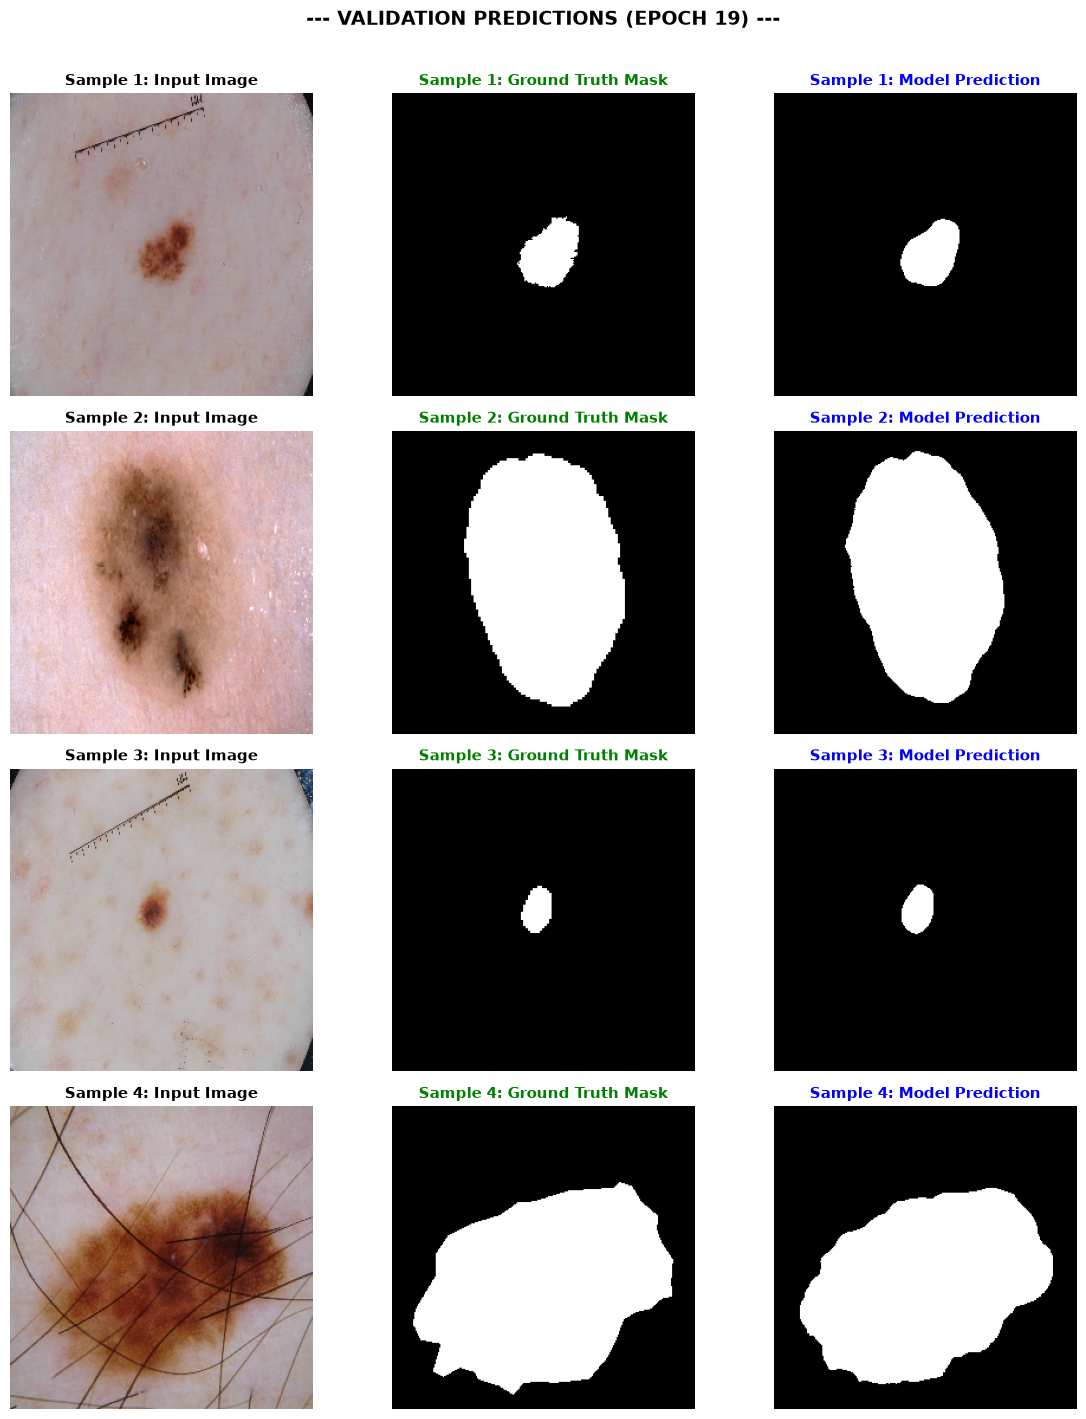

Hoàn thành huấn luyện trong 21.89 phút. Best Val Dice: 0.8971


In [46]:
# 5. Huấn luyện
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=config["epochs"],
    patience=config["patience"],
    save_dir="../checkpoints/dilated_conv_unet"
)

In [ ]:
EXTRA_EPOCHS = 20
PATIENCE = 5
SAVE_DIR = "../checkpoints/context_module_unet"
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_model.pth")

# 1. Tải checkpoint tốt nhất từ lần train trước
if os.path.exists(BEST_MODEL_PATH):
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    last_epoch = checkpoint.get("epoch", 20)
    best_dice = checkpoint.get("best_metric", 0.0)
    print(f" Đã nạp checkpoint từ Epoch {last_epoch} | Best Val Dice trước đó: {best_dice:.4f}")
else:
    print("Không tìm thấy file checkpoint, tiếp tục train trực tiếp từ trọng số hiện tại của model.")
    best_dice = None

# 2. Khởi tạo Optimizer & Scheduler mới cho 20 epoch tiếp theo
# Mẹo: Đặt learning rate nhỏ hơn một chút (ví dụ 5e-5 hoặc 1e-4) để fine-tune tốt hơn
FINETUNE_LR = 5e-5  
optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EXTRA_EPOCHS, eta_min=1e-6)

# 3. Huấn luyện thêm 20 Epochs
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    use_amp=True,                  # Đã an toàn, bật AMP để tăng tốc tối đa
    epochs=EXTRA_EPOCHS,
    patience=PATIENCE,
    save_dir=SAVE_DIR
)

## 9. Testing 

In [47]:
def compute_all_metrics(pred_mask, gt_mask, smooth=1e-6):
    """Tính toán toàn bộ các chỉ số phân đoạn nhị phân cho 1 sample."""
    pred = (pred_mask > 0).astype(np.float32)
    gt = (gt_mask > 0).astype(np.float32)
    TP = (pred * gt).sum()
    FP = (pred * (1.0 - gt)).sum()
    FN = ((1.0 - pred) * gt).sum()
    TN = ((1.0 - pred) * (1.0 - gt)).sum()
    dice = (2.0 * TP + smooth) / (2.0 * TP + FP + FN + smooth)
    iou = (TP + smooth) / (TP + FP + FN + smooth)
    sensitivity = (TP + smooth) / (TP + FN + smooth)
    specificity = (TN + smooth) / (TN + FP + smooth)
    precision = (TP + smooth) / (TP + FP + smooth)
    accuracy = (TP + TN + smooth) / (TP + TN + FP + FN + smooth)
    return {
        "dice": float(dice),
        "iou": float(iou),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "accuracy": float(accuracy),
    }

In [48]:
def evaluate_test_full_metrics(
    model,
    test_loader,
    model_path,
    device,
    num_visualize=5,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
):
    print(f"\n=======================================================")
    print(f"BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST VỚI BEST CHECKPOINT")
    print(f"=======================================================")
    # 1. Nạp checkpoint trọng số
    ckpt = torch.load(model_path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    elif isinstance(ckpt, dict):
        model.load_state_dict(ckpt)
    else:
        model.load_state_dict(ckpt)
    model.to(device)
    model.eval()
    # Lưu trữ toàn bộ kết quả từng mẫu để tính Mean & Std
    all_metrics = {
        "dice": [],
        "iou": [],
        "sensitivity": [],
        "specificity": [],
        "precision": [],
        "accuracy": [],
    }
    mean_arr = np.array(mean, dtype=np.float32)
    std_arr = np.array(std, dtype=np.float32)
    sample_count = 0
    visualized_samples = []
    with torch.no_grad():
        for batch_data in tqdm(test_loader, desc="[Testing Full Metrics]"):
            # Trích xuất image & mask an toàn
            if (
                isinstance(batch_data, (list, tuple))
                and len(batch_data) >= 2
                and isinstance(batch_data[1], torch.Tensor)
            ):
                images = batch_data[0].to(device)
                masks = batch_data[1].to(device)
                has_gt = True
            else:
                images = (
                    batch_data[0].to(device)
                    if isinstance(batch_data, (list, tuple))
                    else batch_data.to(device)
                )
                masks = None
                has_gt = False
            # Forward pass
            outputs = model(images)
            logits = (
                outputs["out"]
                if isinstance(outputs, dict)
                else (outputs[0] if isinstance(outputs, tuple) else outputs)
            )
            preds = (torch.sigmoid(logits) > 0.5).float()
            for b in range(images.size(0)):
                # Khôi phục ảnh RGB gốc
                img_np = images[b].cpu().permute(1, 2, 0).numpy()
                img_orig = np.clip(
                    (img_np * std_arr + mean_arr) * 255.0, 0, 255
                ).astype(np.uint8)
                # Trích xuất mask dự đoán (2D H x W)
                pred_np = (preds[b].squeeze().cpu().numpy() > 0).astype(
                    np.uint8
                )
                if has_gt:
                    gt_np = (masks[b].squeeze().cpu().numpy() > 0).astype(
                        np.uint8
                    )
                    m = compute_all_metrics(pred_np, gt_np)
                else:
                    gt_np = np.zeros_like(pred_np)
                    m = {k: 0.0 for k in all_metrics}
                for k in all_metrics:
                    all_metrics[k].append(m[k])
                sample_count += 1
                # Lưu lại mẫu để visualize bằng Matplotlib
                if len(visualized_samples) < num_visualize:
                    visualized_samples.append(
                        (img_orig, gt_np, pred_np, m if has_gt else None)
                    )
    # 2. Tính trung bình và độ lệch chuẩn
    final_means = {
        f"test/{k}": round(float(np.mean(v)), 4)
        for k, v in all_metrics.items()
    }
    final_stds = {
        f"test/{k}_std": round(float(np.std(v)), 4)
        for k, v in all_metrics.items()
    }
    # 3. In kết quả chi tiết ra màn hình
    print(f"\n=======================================================")
    print(f"KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ CHỈ SỐ TRÊN TẬP TEST:")
    print(f"   Dice Score (F1)    : {final_means['test/dice']:.4f} ± {final_stds['test/dice_std']:.4f}")
    print(f"   IoU (Jaccard)      : {final_means['test/iou']:.4f} ± {final_stds['test/iou_std']:.4f}")
    print(f"   Sensitivity/Recall : {final_means['test/sensitivity']:.4f} ± {final_stds['test/sensitivity_std']:.4f}  (Khả năng bắt tổn thương)")
    print(f"   Specificity        : {final_means['test/specificity']:.4f} ± {final_stds['test/specificity_std']:.4f}  (Nhận diện da lành)")
    print(f"   Precision          : {final_means['test/precision']:.4f} ± {final_stds['test/precision_std']:.4f}")
    print(f"   Pixel Accuracy     : {final_means['test/accuracy']:.4f} ± {final_stds['test/accuracy_std']:.4f}")
    print(f"   Tổng số mẫu test   : {sample_count}")
    print(f"=======================================================\n")
    # 4. Trực quan hóa một số mẫu bằng Matplotlib
    if num_visualize > 0 and len(visualized_samples) > 0:
        n = len(visualized_samples)
        fig, axes = plt.subplots(n, 3, figsize=(12, 3.5 * n))
        if n == 1:
            axes = np.expand_dims(axes, 0)
        for i, (img, gt, pred, m) in enumerate(visualized_samples):
            # Ảnh gốc
            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f"Sample #{i+1}: Original Image")
            axes[i, 0].axis("off")
            # Ground Truth
            axes[i, 1].imshow(gt, cmap="gray")
            axes[i, 1].set_title("Ground Truth")
            axes[i, 1].axis("off")
            # Prediction
            title_pred = "Prediction"
            if m is not None:
                title_pred += f" (Dice: {m['dice']:.3f}, IoU: {m['iou']:.3f})"
            axes[i, 2].imshow(pred, cmap="gray")
            axes[i, 2].set_title(title_pred)
            axes[i, 2].axis("off")
        plt.tight_layout()
        plt.show()
    return final_means, final_stds


BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST VỚI BEST CHECKPOINT


[Testing Full Metrics]: 100%|██████████| 33/33 [00:11<00:00,  2.97it/s]



KẾT QUẢ ĐÁNH GIÁ TOÀN BỘ CHỈ SỐ TRÊN TẬP TEST:
   Dice Score (F1)    : 0.8868 ± 0.1339
   IoU (Jaccard)      : 0.8156 ± 0.1604
   Sensitivity/Recall : 0.9102 ± 0.1232  (Khả năng bắt tổn thương)
   Specificity        : 0.9617 ± 0.1046  (Nhận diện da lành)
   Precision          : 0.8989 ± 0.1547
   Pixel Accuracy     : 0.9543 ± 0.0850
   Tổng số mẫu test   : 520



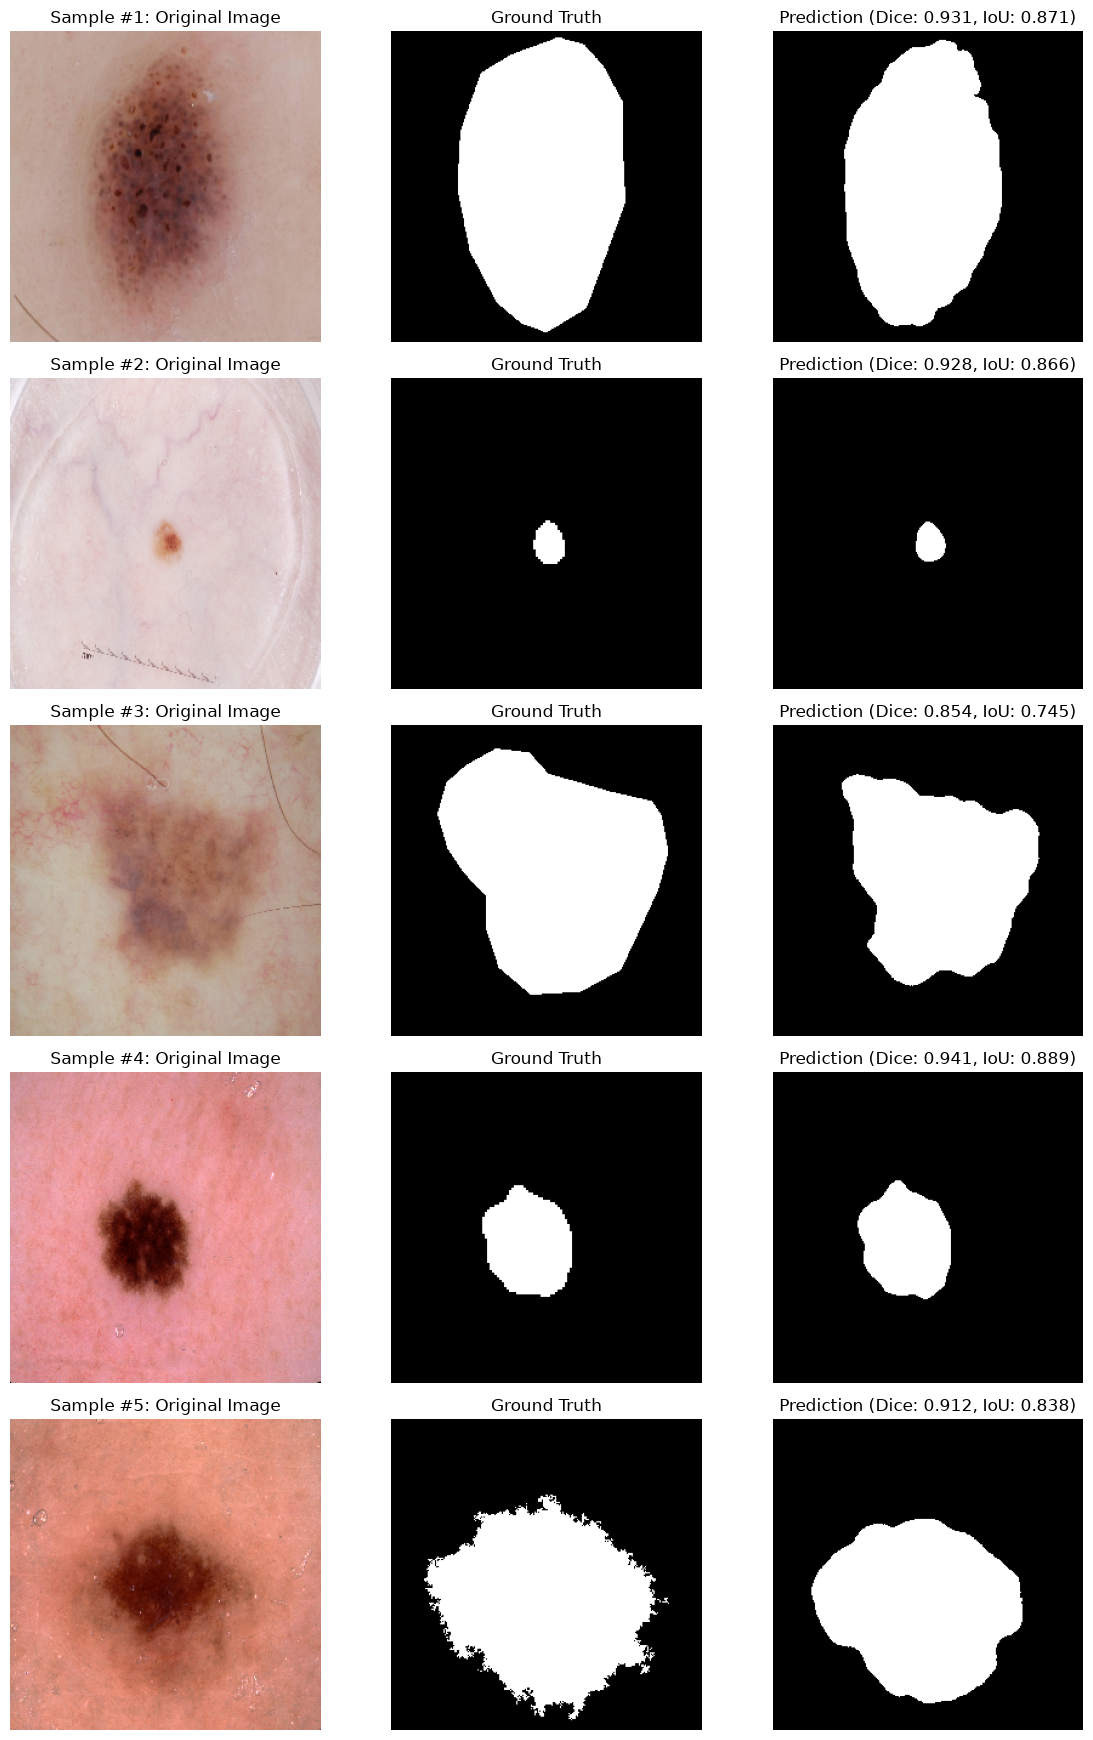

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_channels=3, n_classes=1, bilinear=True).to(device)

_, _, test_loader = get_dataloaders(DATA_DIR, batch_size=16, num_workers=0)
best_checkpoint_path = "../checkpoints/dilated_conv_unet/best_model.pth"
test_means, test_stds = evaluate_test_full_metrics(
    model=model,
    test_loader=test_loader,
    model_path=best_checkpoint_path,
    device=device,
    num_visualize=5,
)
